# Análisis de jugadores NBA

---

Este notebook ejecuta el flujo principal de la aplicación:
- Toma un modelo entrenado para generar embeddings de jugadores de la NBA 
- Aplica clustering sobre los embeddings para agrupar jugadores según su parecido.
- Utiliza otro autoencoder para reducir la dimensionalidad y así analizar y visualizar los resultados.

Este flujo permite comparar la agrupación y representación de los jugadores en el espacio latente aprendido frente a un análisis más simple de agrupación directa y representación con PCA.


`Nota`: Es importante que el modelo que se va a emplear para analizar lás estadísticas se haya entrenado con el mismo tipo de estadisticas(per100pos, per36min o pergame). De lo contrario, no saltaran errores al pasar los datos por el modelo, pero el análisis puede llevar a conclusiones erroneas.

## Preparación

Empezamos por importar las funciones necesarias

In [31]:
%pip install ipympl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from Embeddings import generar_embeddings, guardar_embeddings, cargar_embeddings
from Clustering import generar_clusters, guardar_clusters, cargar_clusters, visual_clusters 


A continuación seleccionamos el archivo con los datos de los jugadores que vamos a analizar. En este caso tomamos las estadísticas de los jugadores de la nba 24-25 que son las de la última temporada jugada completa.

In [3]:
archivo_stats_scout     = r"datasets\nba\finales\scout_pergame_nba24_25.csv"

Seleccionemos los modelos que vamos a usar, tanto  para generar los embeddings como para visualizar los resultados.
En caso de que el modelo de análisis tenga dimensión del espacio latente igual a la dimensión en la que queremos visualizar los resultados(2 o 3) el 2º modelo no sería necesario.

In [ ]:
modelo_analisis = r"" # archivo del autoencoder que genera embeddings
modelo_represnt = r"redes_disponibles\finales\AE_redDim2_dimIN80_.json" # archivo del autoencoder que genera representación visual

Elegimos también el tipo de estadísticas con las que queremos analizar.

In [5]:
modo_stats = "tiro"

Por último, si queremos importar unos embeddings y/o clusters ya generados podemos especificarlo a continuación.

In [20]:
import_emb    = True
archivo_emb   = r"embeddings\emb_scout24_25_shtgStatPG_overcomplete.csv"
import_clst   = True
archivo_clust = r"clusterings\cltr_scout24_25_shtgStatPG_overcomplete_10cltrs.csv"           # archivo CSV donde guardar clusters


## Generar embeddings

Generamos o importamos los embeddings de los jugadores para tenerlos en un diccionario de embeddings.

In [7]:
if import_emb:
    dict_embeddings = cargar_embeddings(archivo_emb)
else:
    dict_embeddings = generar_embeddings(modelo_analisis, archivo_stats_scout, modo_stats)

Veamos que las claves del diccionario son los jugadores.

In [8]:
dict_embeddings.keys()

dict_keys(['Precious Achiuwa', 'Bam Adebayo', 'Ochai Agbaji', 'Santi Aldama', 'Nickeil Alexander-Walker', 'Trey Alexander', 'Grayson Allen', 'Jose Alvarado', 'Kyle Anderson', 'Giannis Antetokounmpo', 'Cole Anthony', 'OG Anunoby', 'Deni Avdija', 'Deandre Ayton', 'Marcus Bagley', 'LaMelo Ball', 'Lonzo Ball', 'Mo Bamba', 'Paolo Banchero', 'Desmond Bane', 'Dalano Banton', 'Dominick Barlow', 'Scottie Barnes', 'RJ Barrett', 'Jamison Battle', 'Nicolas Batum', 'Damion Baugh', 'Bradley Beal', 'Malik Beasley', 'MarJon Beauchamp', 'Reece Beekman', 'Goga Bitadze', 'Anthony Black', 'Bogdan Bogdanović', 'Bol Bol', 'Devin Booker', 'Brandon Boston Jr.', 'Chris Boucher', 'Malaki Branham', 'Christian Braun', 'Mikal Bridges', 'Miles Bridges', 'Malcolm Brogdon', 'Dillon Brooks', 'Keion Brooks Jr.', 'Bruce Brown', 'Jaylen Brown', 'Jalen Brunson', 'Thomas Bryant', 'Kobe Bufkin', 'Alec Burks', 'Jared Butler', 'Jimmy Butler', 'Matas Buzelis', 'Jamal Cain', 'Kentavious Caldwell-Pope', 'Toumani Camara', 'Bub Ca

Sin embargo estos embeddings por si solos no nos dan mucha información por si mismos.

In [9]:
print(dict_embeddings['Precious Achiuwa'])

[ 0.04266282 -0.4444422   0.3463978   0.44360992  0.73102033 -0.36166155
  0.09968114  0.15911086  0.37174365  0.96835715 -0.2319259   0.66080874
 -0.2652079  -0.43838775  1.5148621   0.5852765  -0.4554124  -0.36288106
  0.2297558   1.0873252   1.2573876  -0.13520187  0.23638435 -0.05223817
 -0.2271862  -0.73054063 -0.61744237 -0.37080455 -0.26750356  0.32470056
 -0.09229338 -0.52640575 -0.28303474  0.73085374 -0.2730509  -0.3657148
 -0.05219996  0.7650726  -0.1319828  -0.6951394   0.21579482  1.1036881
 -0.30983073  0.46861914  0.28209955  0.19490573 -0.30260444 -0.82618576
 -0.12257111 -0.8027492   0.12382364  0.12965421 -0.18481958  1.0220519
 -0.01925892 -0.36091387  0.6506708  -0.43483758  1.7417648   0.4869052
  0.4541484  -0.34556907  0.6057919  -0.13507539 -0.451474    0.78051585
 -0.22300285 -0.27985734  0.75107497  0.02073048 -0.45978582 -0.05230474
  0.35696638 -0.29850924  1.5248868   1.5022227  -0.7273136  -0.26442814
 -0.6160004  -0.3294471 ]


## Análisis

El análisis que pretendemos hacer es agrupar los jugadores según similitudes en el estilo de juego de estos. Para esto la función `generar_clusters` emplea el método de K-medias(Kmeans) que agrupa los embeddings por proximidad. 

Empezemos agrupando en 10 clusters para tener una imagen más general.

In [21]:
# Podemos importar clusters ya creados o crear nuevos
if import_clst: 
    dicc_clusters = cargar_clusters(archivo_clust)
else:
    dicc_clusters = generar_clusters(dict_embeddings,10)
dicc_clusters

{'Precious Achiuwa': 4,
 'Bam Adebayo': 5,
 'Ochai Agbaji': 0,
 'Santi Aldama': 6,
 'Nickeil Alexander-Walker': 8,
 'Trey Alexander': 9,
 'Grayson Allen': 8,
 'Jose Alvarado': 8,
 'Kyle Anderson': 7,
 'Giannis Antetokounmpo': 5,
 'Cole Anthony': 6,
 'OG Anunoby': 5,
 'Deni Avdija': 5,
 'Deandre Ayton': 4,
 'Marcus Bagley': 1,
 'LaMelo Ball': 2,
 'Lonzo Ball': 3,
 'Mo Bamba': 1,
 'Paolo Banchero': 5,
 'Desmond Bane': 2,
 'Dalano Banton': 6,
 'Dominick Barlow': 7,
 'Scottie Barnes': 5,
 'RJ Barrett': 5,
 'Jamison Battle': 3,
 'Nicolas Batum': 3,
 'Damion Baugh': 1,
 'Bradley Beal': 2,
 'Malik Beasley': 8,
 'MarJon Beauchamp': 9,
 'Reece Beekman': 7,
 'Goga Bitadze': 4,
 'Anthony Black': 0,
 'Bogdan Bogdanović': 8,
 'Bol Bol': 1,
 'Devin Booker': 2,
 'Brandon Boston Jr.': 6,
 'Chris Boucher': 6,
 'Malaki Branham': 1,
 'Christian Braun': 5,
 'Mikal Bridges': 0,
 'Miles Bridges': 5,
 'Malcolm Brogdon': 5,
 'Dillon Brooks': 6,
 'Keion Brooks Jr.': 0,
 'Bruce Brown': 0,
 'Jaylen Brown': 5,
 '

Ahora que hemos agrupado jugadores podemos buscar jugadores que jugadores se parecen a aquellos en los que estemos interesados. Por ejemplo, tomando a una de las estrellas ofensivas de la liga, Stephen Curry, busquemos que jugadores, segun nuestro modelo,  tienen un estilo similar.

In [23]:
steph_clust = dicc_clusters['Stephen Curry']
n_players = 0
for player, cluster in list(dicc_clusters.items()):
    if cluster == steph_clust:
        n_players += 1
        print(player, cluster)
print(f"Se han encontrado {n_players} similares.")

LaMelo Ball 2
Desmond Bane 2
Bradley Beal 2
Devin Booker 2
Jordan Clarkson 2
Stephen Curry 2
DeMar DeRozan 2
Luka Dončić 2
Kevin Durant 2
Anthony Edwards 2
Darius Garland 2
Keyonte George 2
Paul George 2
Jerami Grant 2
Jalen Green 2
Tyrese Haliburton 2
James Harden 2
Tyler Herro 2
De'Andre Hunter 2
Brandon Ingram 2
Kyrie Irving 2
Cameron Johnson 2
Zach LaVine 2
Damian Lillard 2
Lauri Markkanen 2
Tyrese Maxey 2
CJ McCollum 2
Brandon Miller 2
Donovan Mitchell 2
Malik Monk 2
Trey Murphy III 2
Dejounte Murray 2
Jamal Murray 2
Jordan Poole 2
Michael Porter Jr. 2
Kristaps Porziņģis 2
Norman Powell 2
Immanuel Quickley 2
Austin Reaves 2
Shaedon Sharpe 2
Anfernee Simons 2
Jalen Suggs 2
Jayson Tatum 2
Cam Thomas 2
Myles Turner 2
Victor Wembanyama 2
Coby White 2
Andrew Wiggins 2
Trae Young 2
Se han encontrado 49 similares.


Aunque hemos acotado mucho la búsqueda pero aun nos ha devuelto muchos jugadores, y algunos parecen más similares que otros. 
Veamos los jugadores de una forma más visual que nos permita hacer un análisis mejor. Para esto podemos usar la función `visual_clusters` que emplea el modelo `modelo_represnt` para poder interpretar mejor los embeddings en 2D(o 3D).

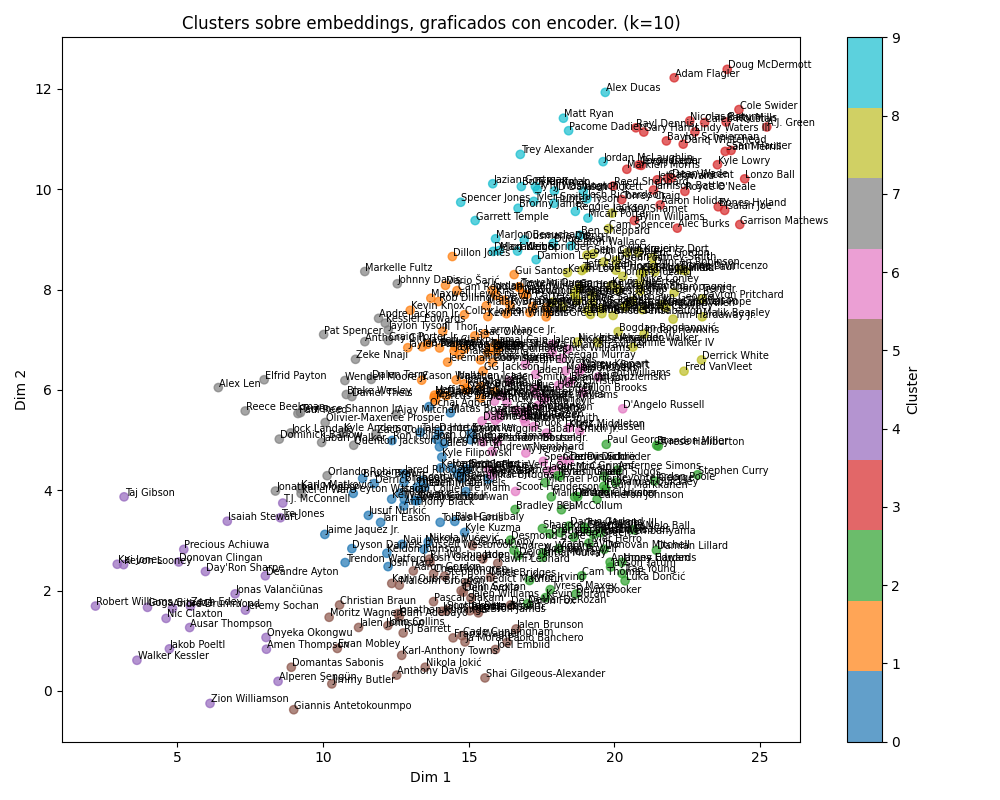

In [24]:
visual_clusters(dict_embeddings,dicc_clusters,10,modelo_represnt)

Podemos ahora generar clusters más restrictivos.

In [25]:
dicc_clusters_2 = generar_clusters(dict_embeddings,20)

In [30]:
steph_clust_2 = dicc_clusters_2['Stephen Curry']
n_players = 0
for player, cluster in list(dicc_clusters_2.items()):
    if cluster == steph_clust_2:
        n_players += 1
        print(player, cluster)
print(f"Se han encontrado {n_players} similares.")

Stephen Curry 18
Keyonte George 18
Paul George 18
Tyrese Haliburton 18
Brandon Miller 18
Jordan Poole 18
Immanuel Quickley 18
D'Angelo Russell 18
Anfernee Simons 18
Jalen Suggs 18
Fred VanVleet 18
Derrick White 18
Se han encontrado 12 similares.


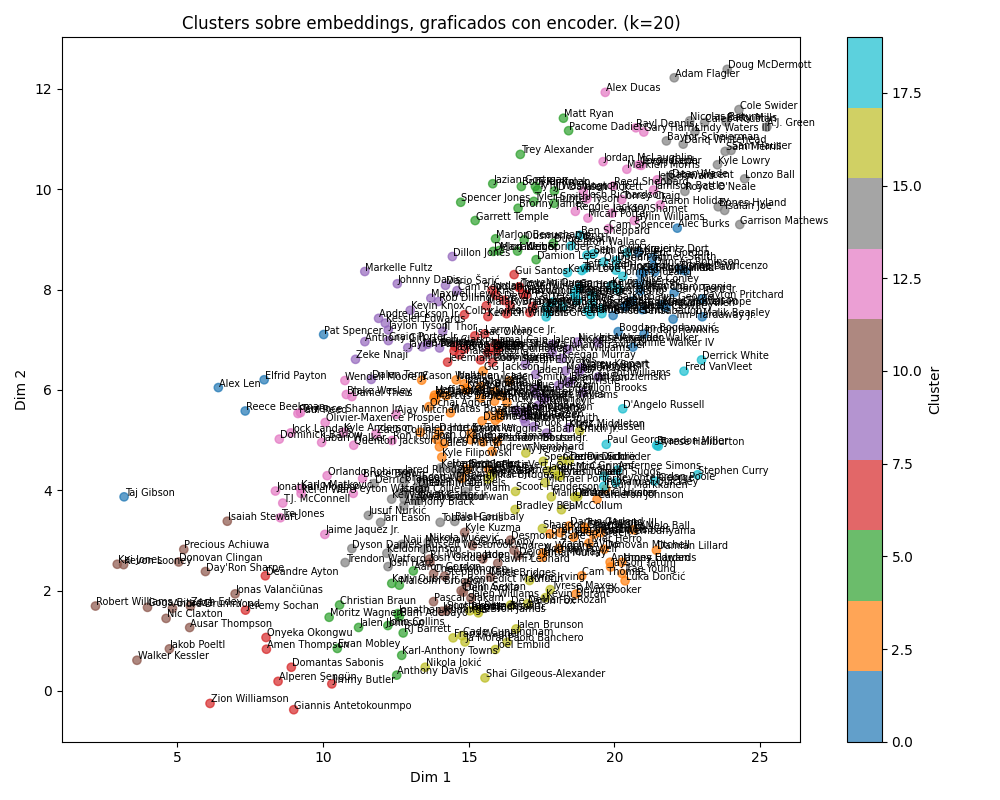

In [28]:
visual_clusters(dict_embeddings,dicc_clusters_2,20,modelo_represnt)